In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_excel('../data/online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=['Customer ID'])

df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [6]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

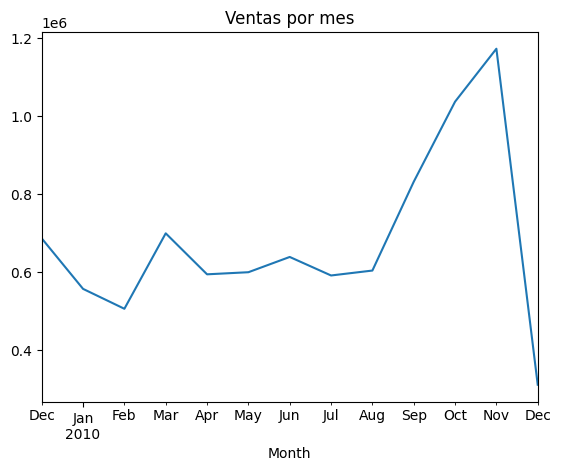

In [8]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

sales_by_month = df.groupby('Month')['TotalPrice'].sum()

sales_by_month.plot()
plt.title("Ventas por mes")
plt.show()

In [9]:
today = df['InvoiceDate'].max()

In [10]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (today - x.max()).days,
    'Invoice': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [11]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [12]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [13]:
def segment(row):
    if row['RFM_Score'] == '555':
        return 'VIP'
    elif int(row['R_score']) >= 4:
        return 'Loyal'
    elif int(row['R_score']) <= 2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [14]:
rfm['Segment'].value_counts()

Segment
At Risk    1703
Loyal      1458
Regular     850
VIP         301
Name: count, dtype: int64

In [15]:
rfm.to_csv('../data/rfm_results.csv')

In [16]:
df = df.rename(columns={
    'Invoice': 'invoice',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'Price': 'price',
    'Customer ID': 'customer_id',
    'Country': 'country'
})

In [17]:
df = df[['invoice', 'stock_code', 'description',
         'quantity', 'invoice_date', 'price',
         'customer_id', 'country']]

df.to_csv('../data/clean_retail.csv', index=False)